
# 10_cartpole_dqn_sb3.ipynb — Phase 1 / Model-Free Deep RL (SB3 / DQN / CartPole)

Bu defter, tez planındaki **Phase 1** adımlarına uygun şekilde hazırlanmıştır.  
İçerir:
- DQN (Stable-Baselines3) eğitimi (CartPole-v1 üzerinde)
- Monitor wrapper
- TensorBoard logları
- Checkpoint/best model kaydı
- pygame render demo


In [1]:

# İlk çalıştırmada gerekirse etkinleştirin:
# %pip install -U "stable-baselines3>=2.3.0" "gymnasium[classic-control]>=0.29.1" tensorboard pandas matplotlib


In [2]:

import os, uuid, time, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.logger import configure
from stable_baselines3.common.utils import set_random_seed

import torch, stable_baselines3 as sb3

print("Python         ", f"{os.sys.version.split()[0]}")
print("Gymnasium      ", gym.__version__)
print("SB3            ", sb3.__version__)
print("PyTorch        ", torch.__version__)
print("CUDA available ", torch.cuda.is_available())
print("MPS available  ", torch.backends.mps.is_available())
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device   ", device)


Python          3.9.6
Gymnasium       1.1.1
SB3             2.6.0
PyTorch         2.7.1
CUDA available  False
MPS available   True
Using device    mps


In [3]:

PHASE = "Phase 1"
NOTEBOOK = "10_cartpole_dqn_sb3"
ALGO = "dqn"
ENV_ID = "CartPole-v1"

SEED = 42
TOTAL_STEPS = 200_000
EVAL_FREQ = 10_000
SAVE_FREQ = 50_000
TB_LOG = True
USE_RENDER_DEMO = True

RUN_ID = time.strftime('%Y%m%d-%H%M%S') + f"-{uuid.uuid4().hex[:6]}"
ROOT_DIR = os.path.join("runs", PHASE, NOTEBOOK, RUN_ID)
CKPT_DIR = os.path.join(ROOT_DIR, "checkpoints")
MONITOR_DIR = os.path.join(ROOT_DIR, "monitor")
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(MONITOR_DIR, exist_ok=True)

print("ROOT_DIR:", ROOT_DIR)
print("CKPT_DIR:", CKPT_DIR)
print("MONITOR :", MONITOR_DIR)

set_random_seed(SEED)
np.random.seed(SEED)


ROOT_DIR: runs/Phase 1/10_cartpole_dqn_sb3/20250929-163256-0a0de1
CKPT_DIR: runs/Phase 1/10_cartpole_dqn_sb3/20250929-163256-0a0de1/checkpoints
MONITOR : runs/Phase 1/10_cartpole_dqn_sb3/20250929-163256-0a0de1/monitor


### Ortam Kurulumu (Monitor + pygame opsiyonu)

In [4]:

def make_env(monitor_dir=None, render=False):
    if render:
        env = gym.make(ENV_ID, render_mode="human")
    else:
        env = gym.make(ENV_ID)
    if monitor_dir is not None:
        env = Monitor(env, monitor_dir)
    return env

train_env = make_env(monitor_dir=MONITOR_DIR, render=False)
eval_env  = make_env(monitor_dir=None, render=False)
obs, info = train_env.reset(seed=SEED)
print("Obs shape:", getattr(obs, "shape", type(obs)), "| Action space:", train_env.action_space)


Obs shape: (4,) | Action space: Discrete(2)


In [ ]:

policy_kwargs = dict(net_arch=[256, 256]) # İki gizli katman, her biri 256 nöron 

model = DQN(
    policy="MlpPolicy",         # Çok katmanlı algılayıcı (MLP) politikası
    env=train_env,              # Eğitim ortamı 
    learning_rate=1e-4,         # Öğrenme hızı (Adam optimizasyonu için)
    buffer_size=100_000,        # Yeniden oynatma tamponu boyutu (FIFO ve çevrimdışı öğrenme için)
    learning_starts=5_000,      # Öğrenmeye başlamadan önce doldurulacak adımlar
    batch_size=128,             # Her eğitim adımında örneklenen geçişlerin sayısı
    gamma=0.99,                 # Gelecekteki ödüller için indirim faktörü
    train_freq=4,               # Her 4 adımda bir eğitim yapılacak 
    gradient_steps=1,           # Her eğitim adımında yapılacak gradyan adımları
    target_update_interval=1_000, # Hedef ağın güncellenme sıklığı
    exploration_fraction=0.2,     # Keşif oranının azalma süresi
    exploration_initial_eps=1.0,  # Başlangıçta tamamen rastgele eylemler
    exploration_final_eps=0.05,     # Sonunda %5 rastgele eylemler  
    policy_kwargs=policy_kwargs,    # Politika ağının mimarisi
    verbose=0,
    device="auto",
    seed=SEED
)

logger_formats = ["stdout","csv"] + (["tensorboard"] if TB_LOG else [])
new_logger = configure(ROOT_DIR, logger_formats)
model.set_logger(new_logger)


Logging to runs/Phase 1/10_cartpole_dqn_sb3/20250929-163256-0a0de1


In [7]:

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=CKPT_DIR,
    log_path=ROOT_DIR,
    eval_freq=EVAL_FREQ,
    deterministic=True,
    render=False
)
ckpt_callback = CheckpointCallback(
    save_freq=SAVE_FREQ,
    save_path=CKPT_DIR,
    name_prefix="ckpt"
)


In [8]:

print(f"[INFO] Training DQN on {ENV_ID} | steps={TOTAL_STEPS} | seed={SEED}")
model.learn(total_timesteps=TOTAL_STEPS, callback=[eval_callback, ckpt_callback], progress_bar=True)
final_model_path = os.path.join(CKPT_DIR, "final_dqn.zip")
model.save(final_model_path)
print("[DONE] Kaydedildi:", final_model_path)


Output()

[INFO] Training DQN on CartPole-v1 | steps=200000 | seed=42
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 23       |
|    ep_rew_mean      | 23       |
|    exploration_rate | 0.998    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 2702     |
|    time_elapsed     | 0        |
|    total_timesteps  | 92       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 24.9     |
|    ep_rew_mean      | 24.9     |
|    exploration_rate | 0.995    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 4558     |
|    time_elapsed     | 0        |
|    total_timesteps  | 199      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 26.8     |
|    ep_rew_mean      | 26.8     |
|    exploration_rate | 0.992 

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 23.2     |
|    ep_rew_mean      | 23.2     |
|    exploration_rate | 0.982    |
| time/               |          |
|    episodes         | 32       |
|    fps              | 5381     |
|    time_elapsed     | 0        |
|    total_timesteps  | 742      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 23.4     |
|    ep_rew_mean      | 23.4     |
|    exploration_rate | 0.98     |
| time/               |          |
|    episodes         | 36       |
|    fps              | 5440     |
|    time_elapsed     | 0        |
|    total_timesteps  | 841      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 23       |
|    ep_rew_mean      | 23       |
|    exploration_rate | 0.978    |
| time/               |          |
|    episodes       

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 22.8     |
|    ep_rew_mean      | 22.8     |
|    exploration_rate | 0.946    |
| time/               |          |
|    episodes         | 100      |
|    fps              | 9419     |
|    time_elapsed     | 0        |
|    total_timesteps  | 2282     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 22.7     |
|    ep_rew_mean      | 22.7     |
|    exploration_rate | 0.944    |
| time/               |          |
|    episodes         | 104      |
|    fps              | 9396     |
|    time_elapsed     | 0        |
|    total_timesteps  | 2360     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 22.6     |
|    ep_rew_mean      | 22.6     |
|    exploration_rate | 0.942    |
| time/               |          |
|    episodes       

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 22.4     |
|    ep_rew_mean      | 22.4     |
|    exploration_rate | 0.921    |
| time/               |          |
|    episodes         | 148      |
|    fps              | 9628     |
|    time_elapsed     | 0        |
|    total_timesteps  | 3321     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 22.5     |
|    ep_rew_mean      | 22.5     |
|    exploration_rate | 0.919    |
| time/               |          |
|    episodes         | 152      |
|    fps              | 9674     |
|    time_elapsed     | 0        |
|    total_timesteps  | 3420     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 23.3     |
|    ep_rew_mean      | 23.3     |
|    exploration_rate | 0.916    |
| time/               |          |
|    episodes       

...

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 118      |
|    ep_rew_mean      | 118      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 2104     |
|    fps              | 1662     |
|    time_elapsed     | 120      |
|    total_timesteps  | 199638   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0405   |
|    n_updates        | 48659    |
----------------------------------


Eval num_timesteps=200000, episode_reward=119.20 +/- 2.99

Episode length: 119.20 +/- 2.99

----------------------------------
| eval/               |          |
|    mean_ep_length   | 119      |
|    mean_reward      | 119      |
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    total_timesteps  | 200000   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.55     |
|    n_updates        | 48749    |
----------------------------------


[DONE] Kaydedildi: runs/Phase 1/10_cartpole_dqn_sb3/20250929-163256-0a0de1/checkpoints/final_dqn.zip


In [9]:

def evaluate_model(mdl, env_, n_episodes=10):
    mean_r, std_r = evaluate_policy(mdl, env_, n_eval_episodes=n_episodes, deterministic=True)
    print(f"[EVAL] MeanReturn={mean_r:.2f} ± {std_r:.2f} over {n_episodes} episodes")
    return mean_r, std_r

best_path = os.path.join(CKPT_DIR, "best_model.zip")
if os.path.exists(best_path):
    best_model = DQN.load(best_path, env=eval_env, device="auto")
    evaluate_model(best_model, eval_env, 10)
else:
    evaluate_model(model, eval_env, 10)


[EVAL] MeanReturn=364.50 ± 15.69 over 10 episodes


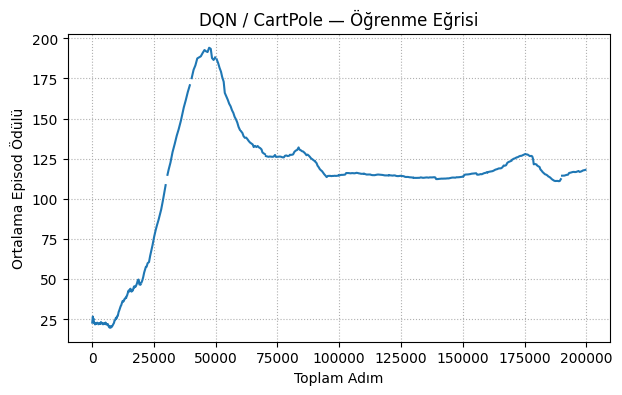

In [10]:

csv_path = os.path.join(ROOT_DIR, "progress.csv")
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    tcol = next((c for c in ["time/total_timesteps","timesteps","total_timesteps"] if c in df.columns), None)
    rcol = next((c for c in ["rollout/ep_rew_mean","ep_rew_mean"] if c in df.columns), None)
    if tcol and rcol:
        plt.figure(figsize=(7,4))
        plt.plot(df[tcol].values, df[rcol].values)
        plt.xlabel("Toplam Adım")
        plt.ylabel("Ortalama Episod Ödülü")
        plt.title("DQN / CartPole — Öğrenme Eğrisi")
        plt.grid(True, linestyle=":", linewidth=0.8)
        plt.show()


In [11]:

def run_render_episodes(mdl, n_episodes=3):
    env_vis = make_env(monitor_dir=None, render=True)
    try:
        for ep in range(n_episodes):
            obs, info = env_vis.reset(seed=SEED+ep)
            done = truncated = False
            total_r = 0.0
            while not (done or truncated):
                action, _ = mdl.predict(obs, deterministic=True)
                obs, reward, done, truncated, _ = env_vis.step(action)
                total_r += reward
            print(f"[RENDER] Episode {ep+1} Return={total_r}")
    finally:
        env_vis.close()

if USE_RENDER_DEMO:
    mdl = best_model if 'best_model' in globals() else model
    run_render_episodes(mdl, 3)


[RENDER] Episode 1 Return=391.0
[RENDER] Episode 2 Return=346.0
[RENDER] Episode 3 Return=334.0


In [12]:

meta = {
    "phase": PHASE,
    "notebook": NOTEBOOK,
    "algo": ALGO.upper(),
    "env_id": ENV_ID,
    "seed": SEED,
    "total_steps": TOTAL_STEPS,
    "run_id": RUN_ID,
    "root_dir": ROOT_DIR,
    "ckpt_dir": CKPT_DIR,
    "monitor_dir": MONITOR_DIR,
    "created_at": time.strftime('%Y-%m-%d %H:%M:%S')
}
with open(os.path.join(ROOT_DIR, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)
print(json.dumps(meta, indent=2))


{
  "phase": "Phase 1",
  "notebook": "10_cartpole_dqn_sb3",
  "algo": "DQN",
  "env_id": "CartPole-v1",
  "seed": 42,
  "total_steps": 200000,
  "run_id": "20250929-163256-0a0de1",
  "root_dir": "runs/Phase 1/10_cartpole_dqn_sb3/20250929-163256-0a0de1",
  "ckpt_dir": "runs/Phase 1/10_cartpole_dqn_sb3/20250929-163256-0a0de1/checkpoints",
  "monitor_dir": "runs/Phase 1/10_cartpole_dqn_sb3/20250929-163256-0a0de1/monitor",
  "created_at": "2025-09-29 16:36:55"
}


## Hiperparametre Tune Önerileri
* exploration_fraction: 0.2 → 0.4 (daha yavaş düşsün)
* exploration_final_eps: 0.05 → 0.02 (uzun vadede az da olsa keşif)
* Beklenti: İlk 80k-100k adımda ep_rew_mean biraz daha geç ama daha yüksek plato.
* Gelecek odak (γ) — daha uzun denge
* gamma: 0.99 → 0.995
* Beklenti: ep_len_mean artar; kayıp eğrisi dalgalanabilir ama uzun bölüm istikrarı kazanır.
* Hedef ağ periyodu — aşırı “overshoot” azaltma
* target_update_interval: 1000 → 500 ve ayrı koşuda 2000 (iki farklı deney)
* Beklenti: 500’de daha sık, daha “yakın” hedef; 2000’de daha durağan ama yavaş tepki. Grafikte zirve–plato farkı azalmalı.
* Öğrenme oranı — faz farkı düzeltme
* learning_rate: 1e-4 → 2.5e-4 (ve ayrı koşuda 5e-5)
* Beklenti: 2.5e-4 ile erken yükseliş hızlanır, ama dalgalanma artabilir; 5e-5 ile daha yavaş ama stabil yükseliş.
* Veri verimliliği — daha çok “update per env step”
* train_freq=4, gradient_steps=1 → gradient_steps=4 (train_freq aynı)
* Beklenti: Aynı çevre adımında daha çok güncelleme ⇒ ep_rew_mean daha hızlı toparlanabilir; fazla olursa overfit/dalgalanma.
* Replay kapasitesi ve ısınma
* buffer_size: 100_000 → 200_000
* learning_starts: 5_000 → 10_000
* Beklenti: Daha çeşitli batch’ler, daha düzgün train/loss; plato seviyesi biraz yükselebilir.
* Not: Her koşuyu RUN_ID farklı klasörde tutuyoruz. Senin log yapın zaten buna uygun:
* ROOT_DIR: TB + progress.csv
* CKPT_DIR: best_model.zip, ckpt_*, final_dqn.zip
* MONITOR_DIR: epizot ham kayıtları